In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from  sklearn.preprocessing import MinMaxScaler,StandardScaler

In [5]:
df=pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [6]:
df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes
...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         100 non-null    int64  
 1   Age                 90 non-null     float64
 2   Gender              100 non-null    object 
 3   Department          90 non-null     object 
 4   Education           90 non-null     object 
 5   Experience_Years    100 non-null    int64  
 6   Monthly_Salary      90 non-null     float64
 7   Performance_Rating  100 non-null    int64  
 8   City                90 non-null     object 
 9   Attrition           100 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 7.9+ KB


In [8]:
df.isnull()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False
97,False,False,False,True,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [10]:
df['Age_mean_imputed']=df['Age'].fillna(df['Age'].mean())
df['Salary_mean_imputed']=df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())

In [11]:
df['Department_mode_imputed']=df['Department'].fillna(df['Department'].mode()[0])

In [12]:
df['Education_mode_imputed']=df['Education'].fillna(df['Education'].mode()[0])

In [13]:
df['City_mode_imputed']=df['City'].fillna(df['City'].mode()[0])

In [14]:
sns.set(style='whitegrid')

/tmp/ipykernel_2527/838478184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Age',y='Experience_Years',palette='pastel')


<Axes: xlabel='Age', ylabel='Experience_Years'>

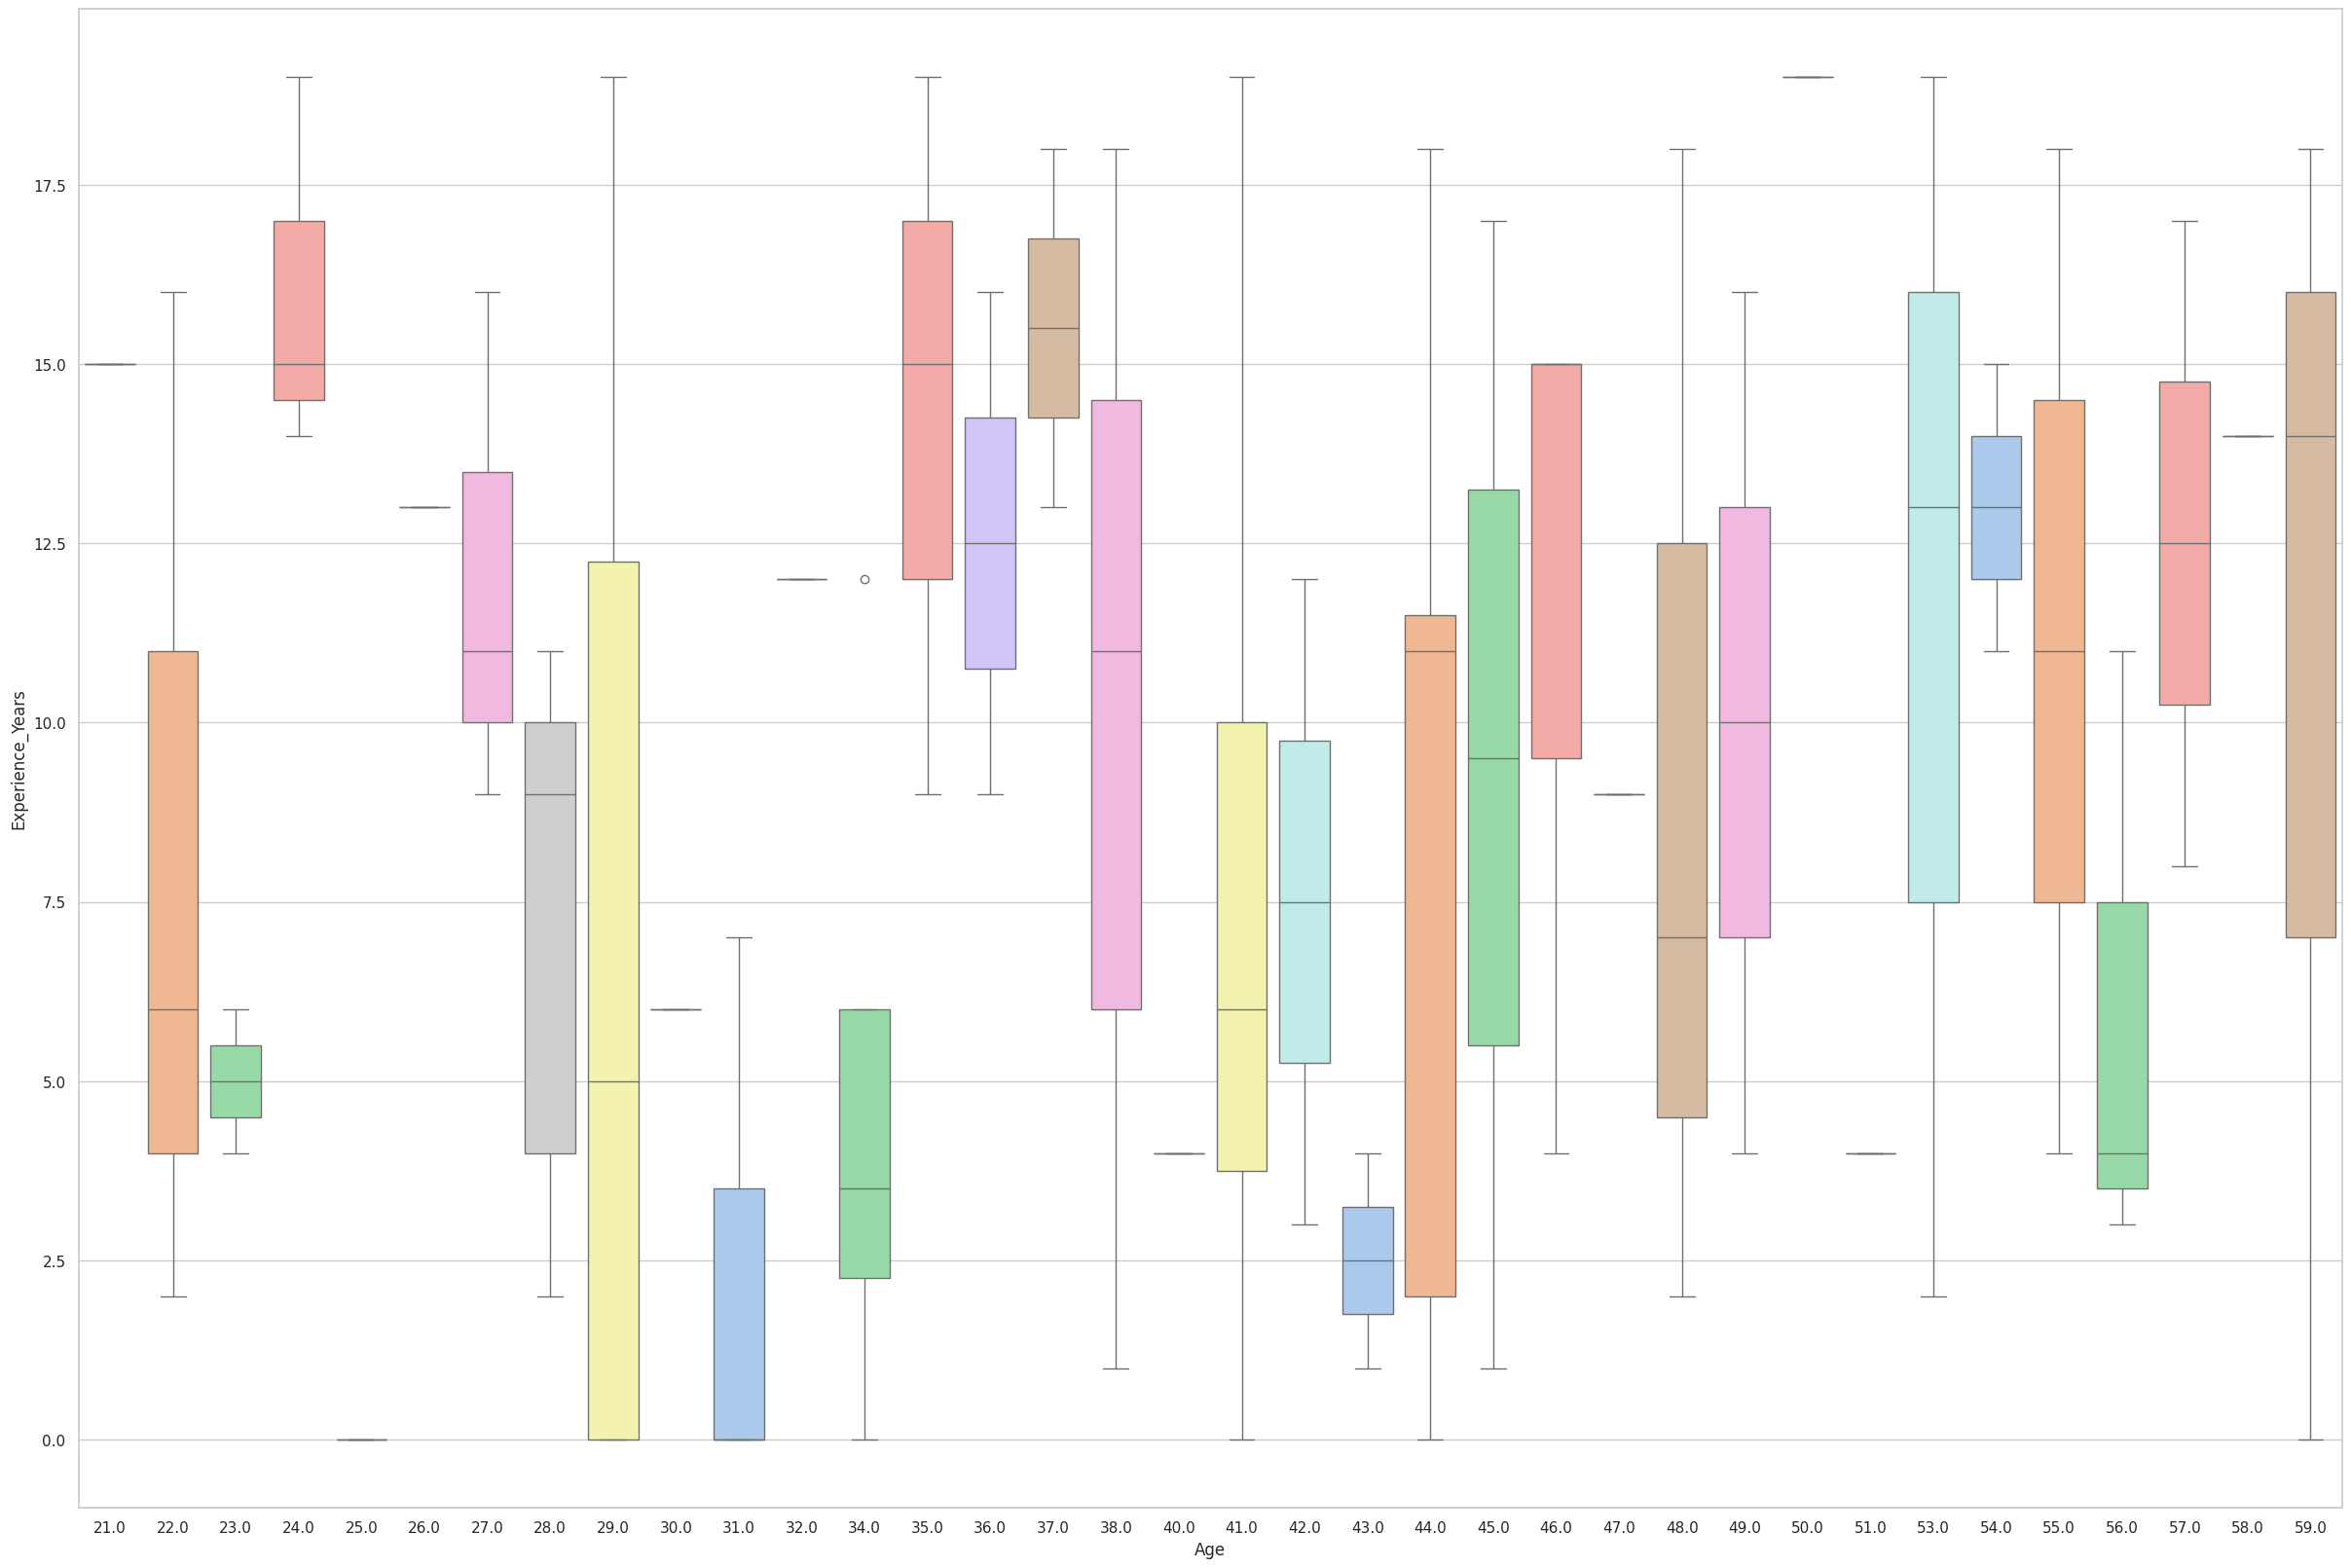

In [15]:
plt.figure(figsize=(30,20))
sns.boxplot(data=df,x='Age',y='Experience_Years',palette='pastel')

Text(0, 0.5, 'Experience_Years')

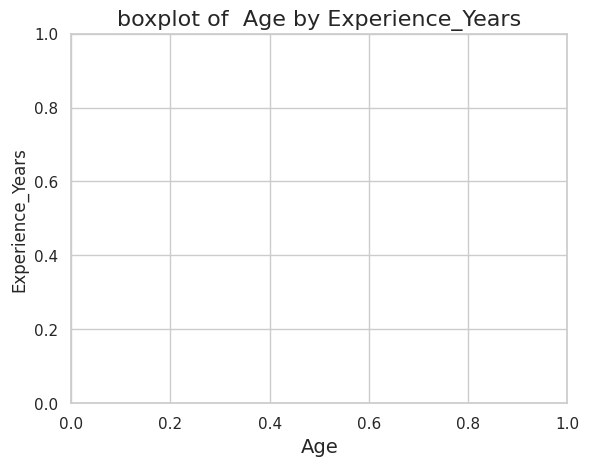

In [16]:
plt.title('boxplot of  Age by Experience_Years',fontsize=16)
plt.xlabel('Age',fontsize=14)
plt.ylabel('Experience_Years',fontsize=12)

/tmp/ipykernel_2527/666875047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Age',y='Monthly_Salary',palette='pastel')


<Axes: xlabel='Age', ylabel='Monthly_Salary'>

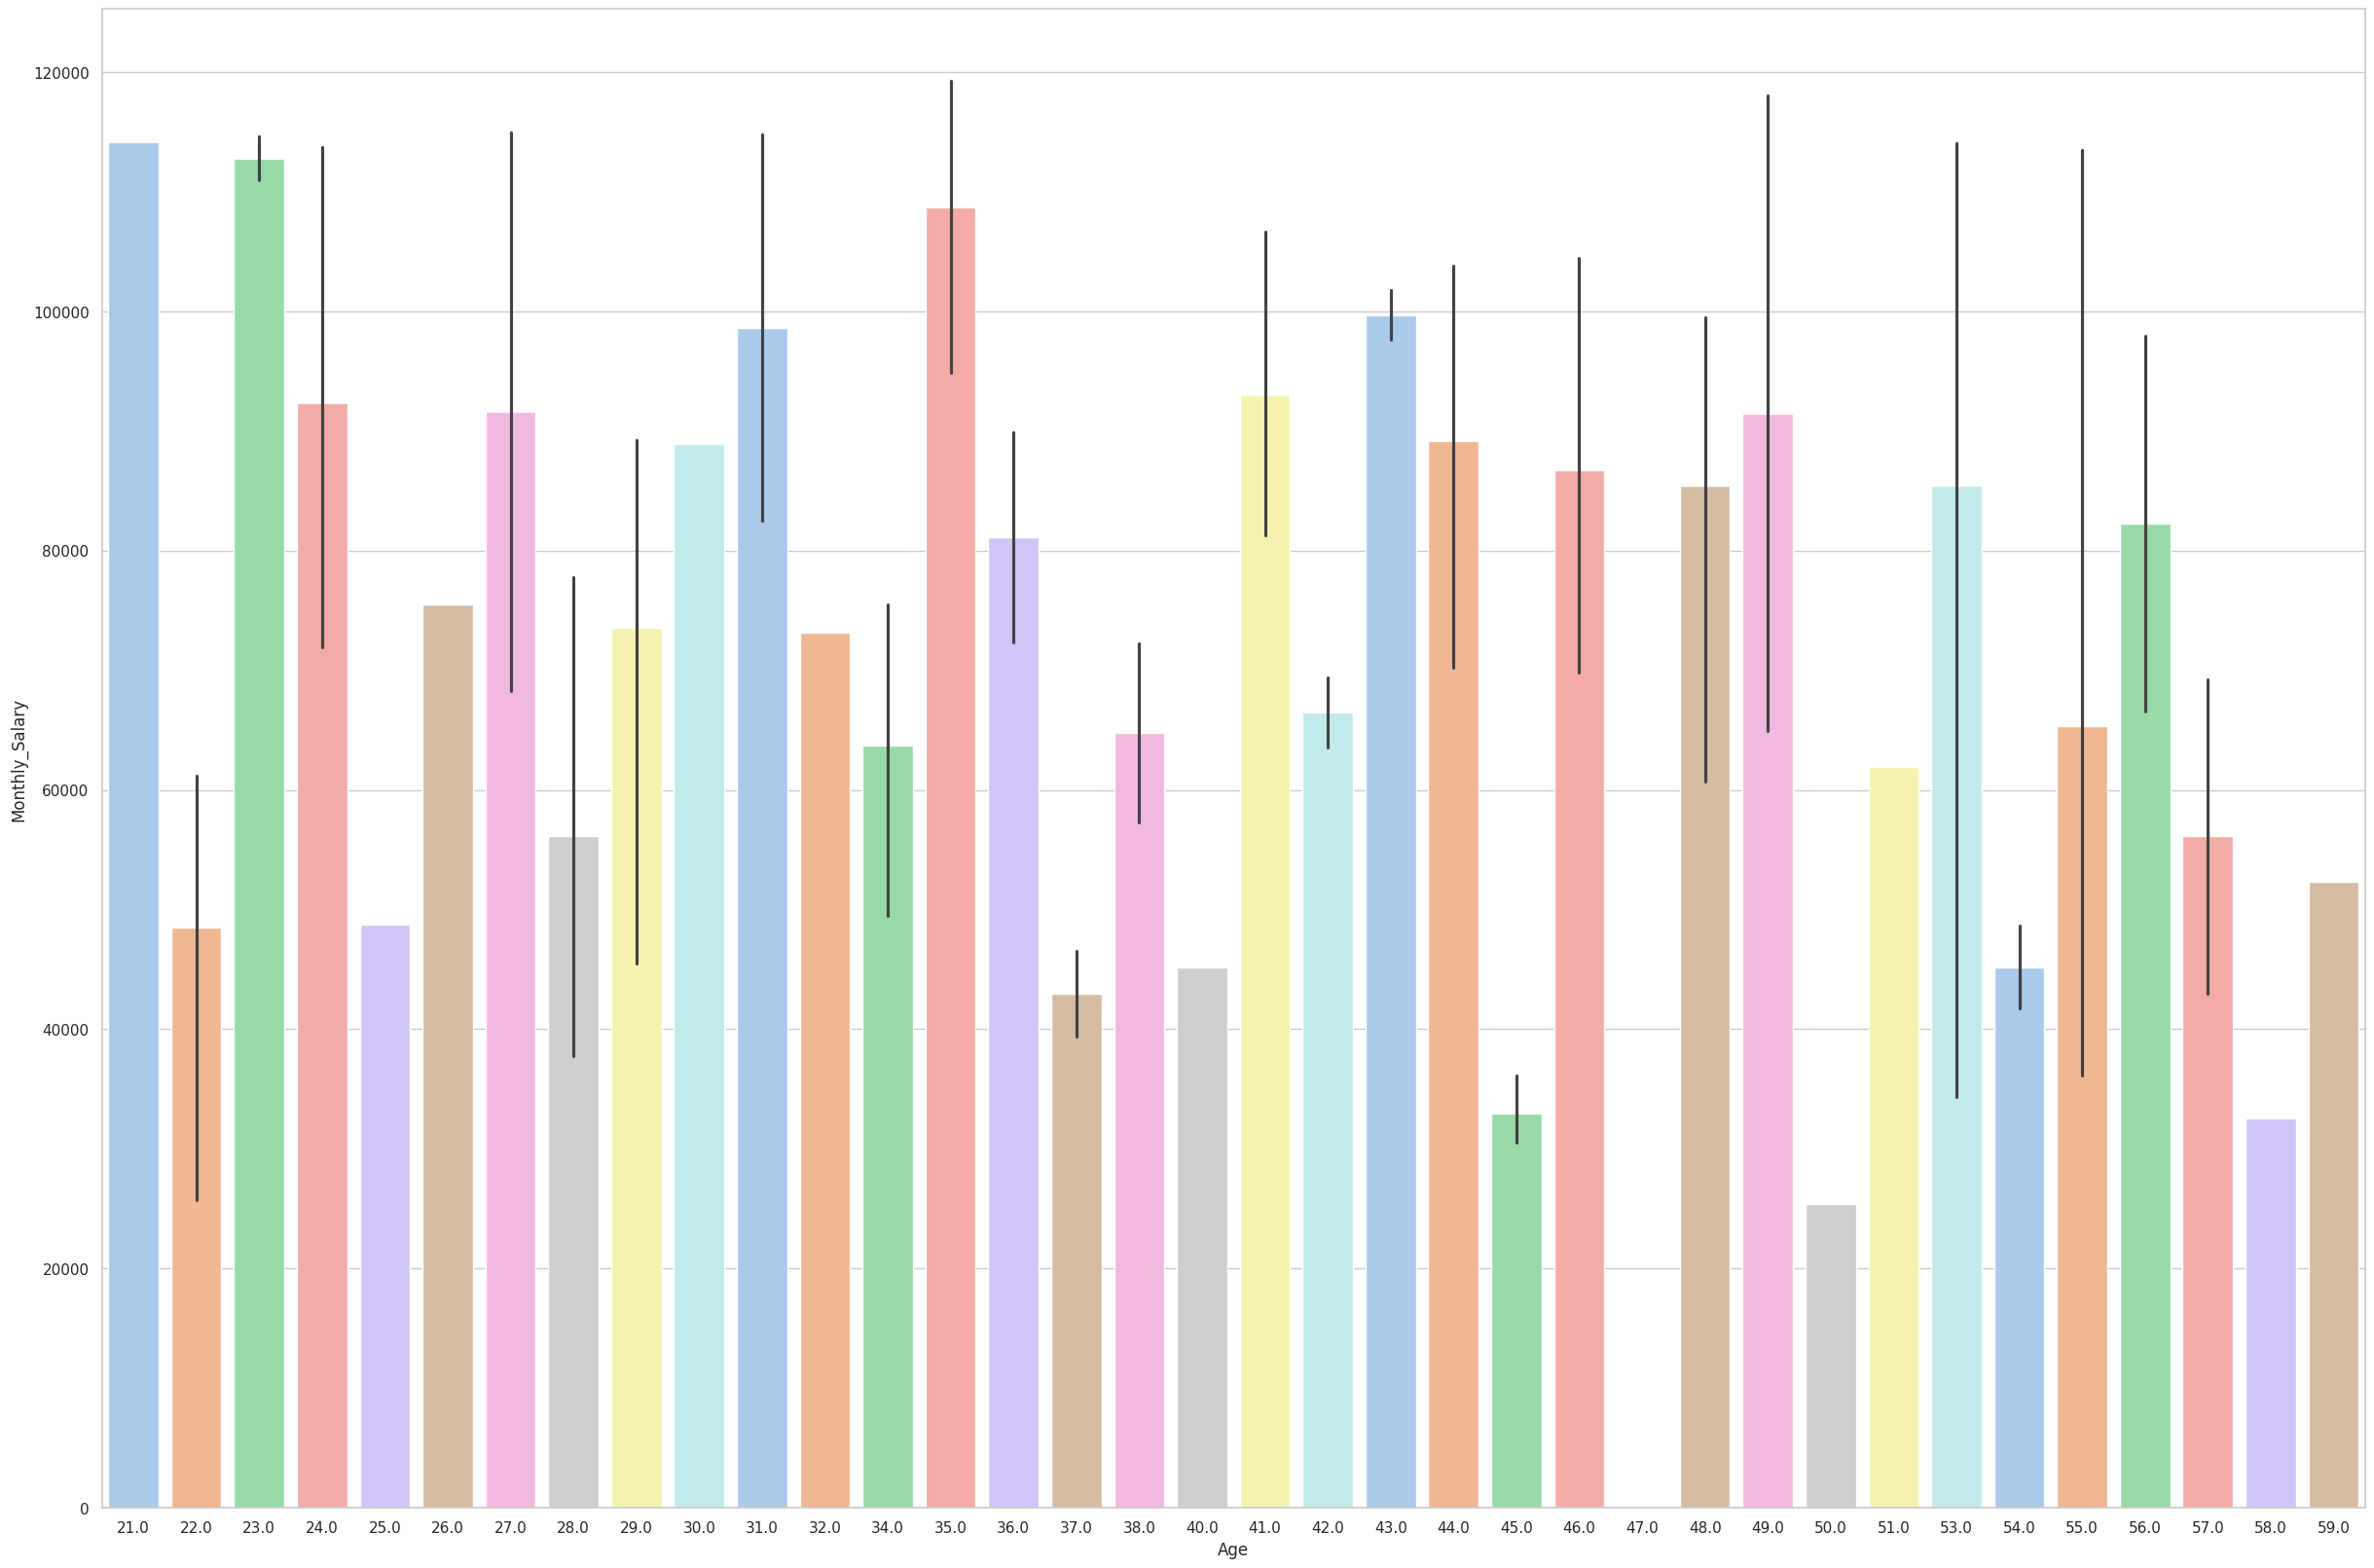

In [17]:
plt.figure(figsize=(30,20))
sns.barplot(data=df,x='Age',y='Monthly_Salary',palette='pastel')

Text(0, 0.5, 'Monthly_Salary')

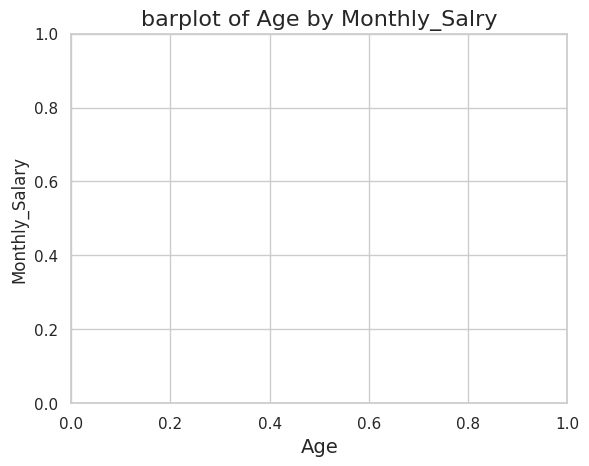

In [18]:
plt.title('barplot of Age by Monthly_Salry',fontsize=16)
plt.xlabel('Age',fontsize=14)
plt.ylabel('Monthly_Salary',fontsize=12)

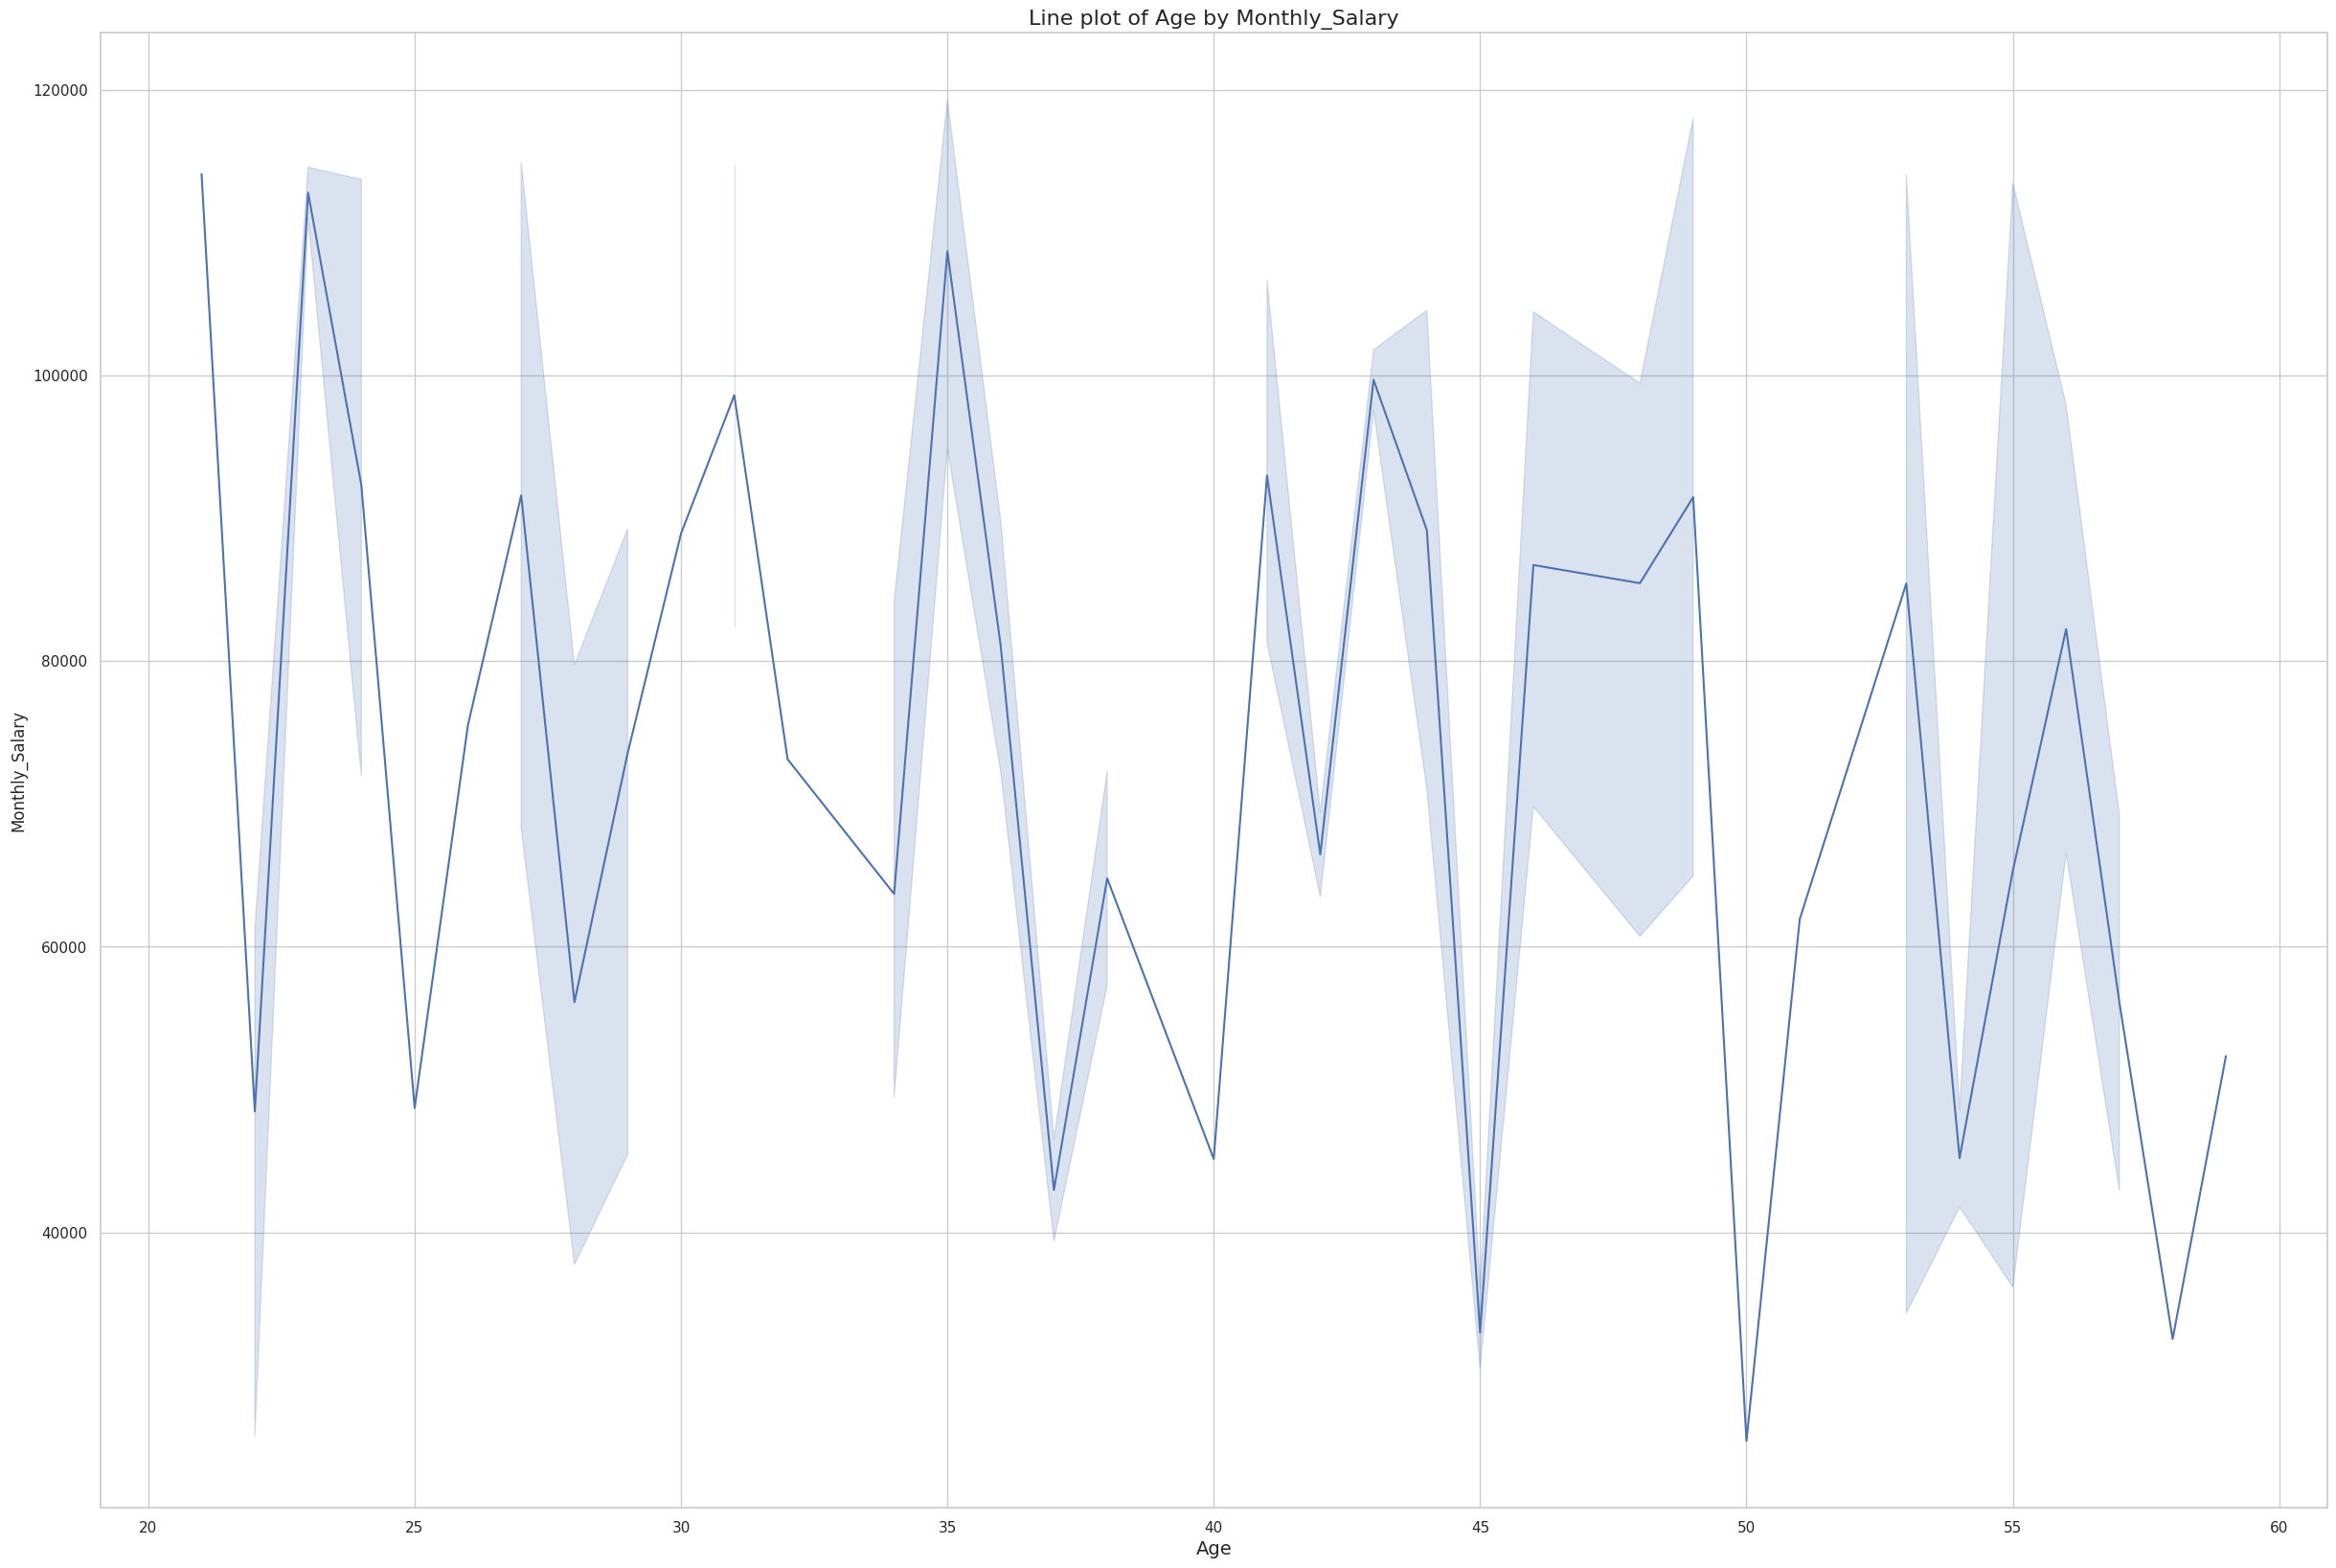

In [19]:
plt.figure(figsize=(30,20))
sns.lineplot(data=df,x='Age',y='Monthly_Salary')
plt.title('Line plot of Age by Monthly_Salary',fontsize=16)
plt.xlabel('Age',fontsize=14)
plt.ylabel('Monthly_Salary',fontsize=12)
plt.show()

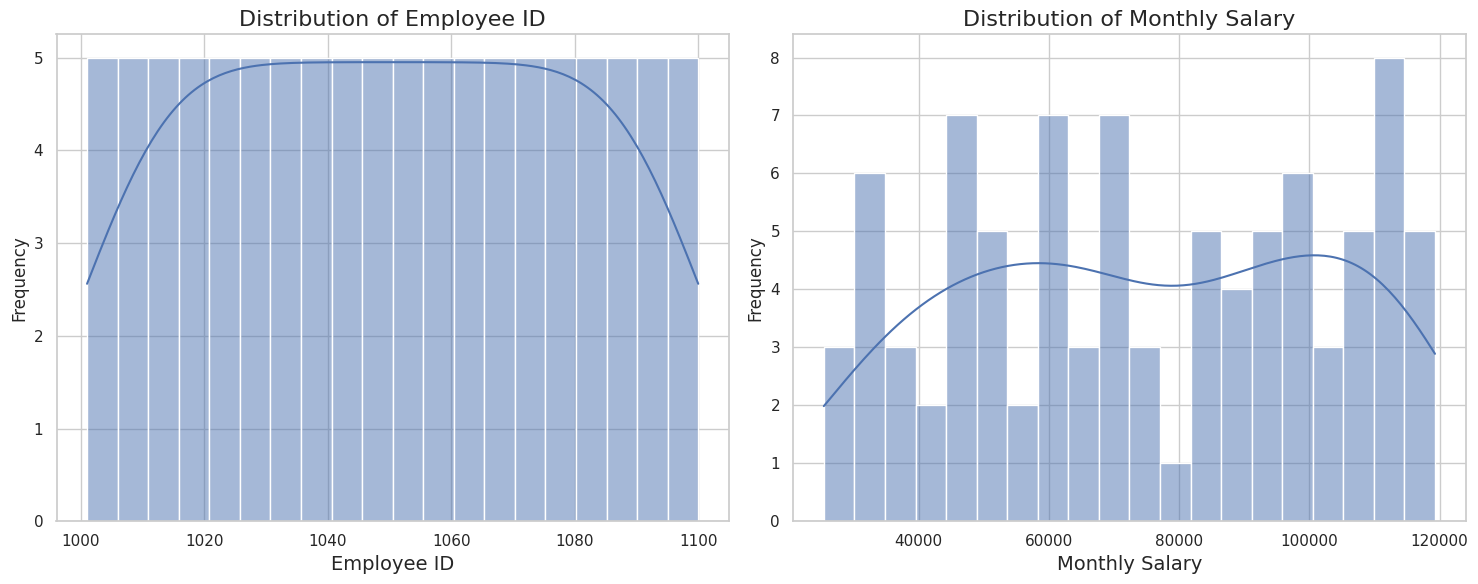

In [20]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Employee_ID'], bins=20, kde=True)
plt.title('Distribution of Employee ID', fontsize=16)
plt.xlabel('Employee ID', fontsize=14)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['Monthly_Salary'], bins=20, kde=True)
plt.title('Distribution of Monthly Salary', fontsize=16)
plt.xlabel('Monthly Salary', fontsize=14)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

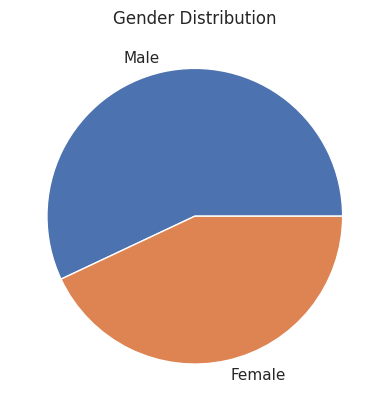

In [21]:


# 1. Count how many people are in each Gender category
gender_counts = df['Gender'].value_counts()

# 2. Create the basic pie chart
plt.pie(x=gender_counts.values, labels=gender_counts.index)

# 3. Add a simple title
plt.title('Gender Distribution')

# 4. Show the chart
plt.show()

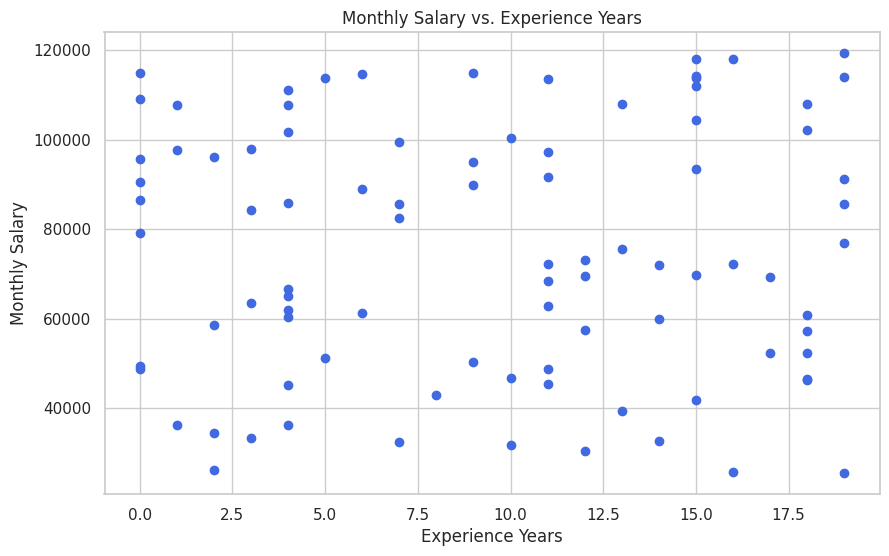

In [22]:


# Create the basic dot graph
plt.figure(figsize=(10, 6))
plt.scatter(x=df['Experience_Years'], y=df['Monthly_Salary'], color='royalblue')

# Add titles and labels
plt.title('Monthly Salary vs. Experience Years')
plt.xlabel('Experience Years')
plt.ylabel('Monthly Salary')

# Show the plot
plt.show()

In [23]:
encoded_data=df.copy()

In [24]:
label_encoder=LabelEncoder()
encoded_data['Gender_Label']=label_encoder.fit_transform(encoded_data['Gender'])

In [25]:
one_hot_encoded = pd.get_dummies(encoded_data['Department'], prefix='Department')
encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)

In [26]:
encoded_data["Gender_Label"]

,Gender_Label
0,1
1,0
2,0
3,0
4,1
...,...
95,0
96,1
97,1
98,0


In [27]:
encoded_data

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,...,Salary_mean_imputed,Department_mode_imputed,Education_mode_imputed,City_mode_imputed,Gender_Label,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,...,52350.0,HR,Masters,Calicut,1,False,True,False,False,False
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,...,118008.0,Marketing,Bachelors,Chennai,0,False,False,False,True,False
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,...,119297.0,HR,Masters,Kochi,0,False,True,False,False,False
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,...,50351.0,HR,PhD,Trivandrum,0,False,True,False,False,False
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,...,113668.0,IT,Bachelors,Trivandrum,1,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,...,48625.0,HR,Masters,Chennai,0,False,True,False,False,False
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,...,107873.0,Marketing,Masters,Trivandrum,1,False,False,False,True,False
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,...,97592.0,HR,PhD,Chennai,1,False,False,False,False,False
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,...,102052.0,Marketing,PhD,Calicut,0,False,False,False,True,False


In [28]:
numerical_columns=['Age','Monthly_Salary','Experience_Years']
df.dropna(subset=numerical_columns,inplace=True)

#initialize scalers
min_max_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

#Apply min max scaling
df['Age_minmax']=min_max_scaler.fit_transform(df[['Age']])

#Apply standard scaling
df['Age_standard']=standard_scaler.fit_transform(df[['Age']])

In [29]:
df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,Age_mean_imputed,Salary_mean_imputed,Department_mode_imputed,Education_mode_imputed,City_mode_imputed,Age_minmax,Age_standard
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,59.0,52350.0,HR,Masters,Calicut,1.000000,1.811984
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,49.0,118008.0,Marketing,Bachelors,Chennai,0.736842,0.889855
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,35.0,119297.0,HR,Masters,Kochi,0.368421,-0.401126
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,28.0,50351.0,HR,PhD,Trivandrum,0.184211,-1.046617
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,41.0,113668.0,IT,Bachelors,Trivandrum,0.526316,0.152151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,54.0,48625.0,HR,Masters,Chennai,0.868421,1.350919
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,53.0,107873.0,Marketing,Masters,Trivandrum,0.842105,1.258706
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,43.0,97592.0,HR,PhD,Chennai,0.578947,0.336577
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,44.0,102052.0,Marketing,PhD,Calicut,0.605263,0.428790
